# Tarea 4 Clasificación
En este ejercicio aplicarás tres modelos de clasificación:
- K-Nearest Neighbors (KNN)
- Naive Bayes
- Regresión Logística

El objetivo es detectar un hongo es comestible o venenoso según sus especificaciones como la forma del sombrero, el color del sombrero, el color de las branquias, etc.

In [19]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [20]:
df = pd.read_csv("mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [22]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


Observa como se distribuye tu variable target "class". Presenta un desbalanceo grave/moderado/bajo?

In [23]:
class_distribution = df['class'].value_counts()
print("Distribución de la variable 'class':\n", class_distribution)

Distribución de la variable 'class':
 class
e    4208
p    3916
Name: count, dtype: int64


Asegura que tus variables sean del tipo category

In [24]:
df = df.apply(lambda x: x.astype('category'))

Transforma tus variables categorias, como todas las variables que tienes son categoricas, preguntate si vale la pena usar mejor one hot encoding o label encoding. 

In [25]:
le = LabelEncoder()

for column in df.columns:
    df[column] = le.fit_transform(df[column])

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


Revisa la cardinalidad de las columnas que tienes y verifica si todas aportan valor o existe alguna que puedas eliminar

In [26]:
cardinality = df.nunique()
print(cardinality)

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64


Divide tus datos en entrenamiento y prueba

In [27]:
X = df.drop("class", axis=1)  # Características
y = df["class"]  # Etiqueta

# 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Entrena los siguentes 3 modelos:
- Regresion logistica
- KNN (tunea el hiperparametro de la K)
- Naive Bayes

In [28]:
# Entrenamiento de los modelos

# Regresión Logística
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# KNN (con k=3 como ejemplo, se puede tunear más adelante)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

Haz predicciones e imprime:
- Metricas en train y test
- Matriz de confusion
- Reporte de clasificacion

In [29]:
# Evaluación de los modelos

# Reporte de clasificación para KNN
print("Reporte de clasificación para KNN:\n", classification_report(y_test, y_pred_knn))

# Reporte de clasificación para Naive Bayes
print("Reporte de clasificación para Naive Bayes:\n", classification_report(y_test, y_pred_nb))

# Reporte de clasificación para Regresión Logística
print("Reporte de clasificación para Regresión Logística:\n", classification_report(y_test, y_pred_lr))

Reporte de clasificación para KNN:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

Reporte de clasificación para Naive Bayes:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       843
           1       0.91      0.93      0.92       782

    accuracy                           0.92      1625
   macro avg       0.92      0.92      0.92      1625
weighted avg       0.92      0.92      0.92      1625

Reporte de clasificación para Regresión Logística:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95       843
           1       0.94      0.95      0.95       782

    accuracy                           0.95      1

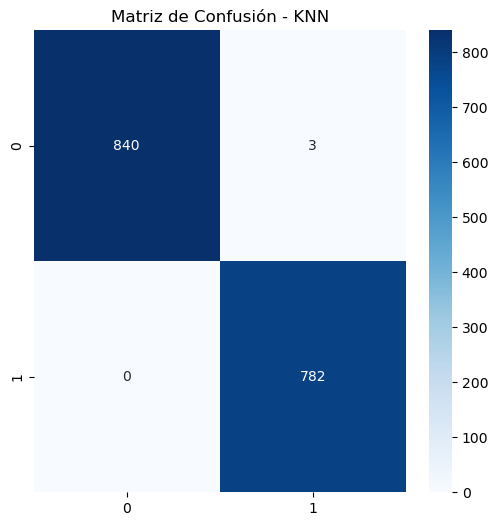

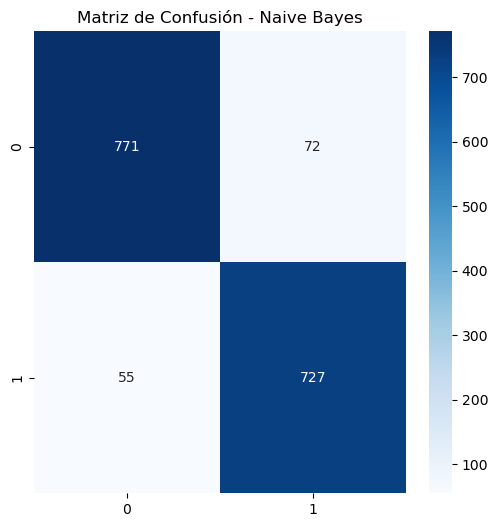

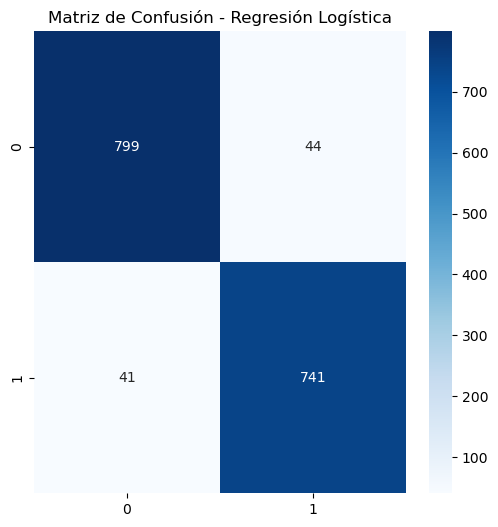

In [30]:
# Matriz de Confusión para KNN
plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - KNN")
plt.show()

# Matriz de Confusión para Naive Bayes
plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Naive Bayes")
plt.show()

# Matriz de Confusión para Regresión Logística
plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

Utiliza la curva ROC para elegir el mejor modelo

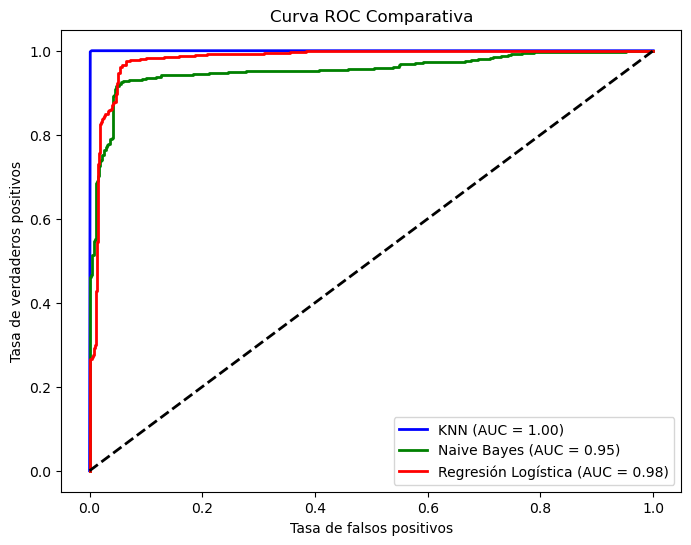

In [31]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC para cada modelo
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn.predict_proba(X_test)[:, 1])
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb.predict_proba(X_test)[:, 1])
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test)[:, 1])

# Calcular el AUC
roc_auc_knn = auc(fpr_knn, tpr_knn)
roc_auc_nb = auc(fpr_nb, tpr_nb)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Graficar la curva ROC
plt.figure(figsize=(8,6))
plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, label=f'KNN (AUC = {roc_auc_knn:.2f})')
plt.plot(fpr_nb, tpr_nb, color='green', lw=2, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')
plt.plot(fpr_lr, tpr_lr, color='red', lw=2, label=f'Regresión Logística (AUC = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.title('Curva ROC Comparativa')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend(loc='lower right')
plt.show()
